# IMPORT THƯ VIỆN CẦN THIẾT 

In [3]:

from scipy.stats import chi2_contingency
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
from sklearn.linear_model import LassoCV
from sklearn.metrics import mean_absolute_error, r2_score

In [4]:
# Hàm phân tích biến phân loại
from scipy.stats import chi2_contingency
from scipy import stats
def check_chi_square(df, col1, col2):
    """
    Hàm kiểm tra tính độc lập giữa 2 biến phân loại bằng Chi-Square.
    Nhằm phát hiện đa cộng tuyến phân loại.
    """
    # 1. Lập bảng tần suất chéo (Contingency Table) giữa 2 biến
    contingency_table = pd.crosstab(df[col1], df[col2])
    
    # 2. Chạy kiểm định Chi-Square
    chi2_stat, p_value, dof, expected = chi2_contingency(contingency_table) # 
    
    # 3. In kết quả trực quan
    print(f"--- KIỂM ĐỊNH CHI-SQUARE: [{col1}] & [{col2}] ---")
    print(f"Giá trị thống kê χ² : {chi2_stat:.4f}")
    print(f"p-value             : {p_value:.4f}") # In ra p-value của kiểm định


def filter_by_anova_eta(df, cat_col, target_col): 
    """
    Sử dụng kiểm định ANOVA : ANOVA (Phân tích phương sai - Analysis of Variance) 
    là một phương pháp thống kê được sử dụng để kiểm tra xem có sự khác biệt có ý nghĩa thống kê giữa giá trị trung bình của 2, ba nhóm trở lên hay không. (Kiểm định với p-value)
    Giúp phân tích tác động của các biến phân loại (độc lập) lên một biến liên tục (phụ thuộc)
    
    và chỉ số Eta-squared (η²).
    """
    # Lọc bỏ các dòng có giá trị NaN ở 2 cột đang xét để hàm không bị lỗi
    valid_data = df[[cat_col, target_col]].dropna()
    
    # 1. CHUẨN BỊ DỮ LIỆU CHO ANOVA
    # Tách biến mục tiêu thành các mảng (arrays) riêng biệt theo từng nhóm phân loại
    groups = [group[target_col].values for name, group in valid_data.groupby(cat_col)]
    
    # 2. CHẠY KIỂM ĐỊNH ANOVA
    f_stat, p_value = stats.f_oneway(*groups)
    
    # 3. TÍNH TOÁN ETA-SQUARED (η²)
    # Tính trung bình của toàn bộ biến mục tiêu
    mean_total = valid_data[target_col].mean()
    
    # Tính Sum of Squares Total (SST)
    ss_total = ((valid_data[target_col] - mean_total) ** 2).sum()
    
    # Tính Sum of Squares Between (SSB)
    ss_between = 0
    for name, group in valid_data.groupby(cat_col):
        ss_between += len(group) * ((group[target_col].mean() - mean_total) ** 2)
        
    # Công thức Eta-squared
    eta_squared = ss_between / ss_total
    
    # 4. TRÌNH BÀY KẾT QUẢ
    print(f"--- ĐÁNH GIÁ BIẾN: [{cat_col}] tác động lên [{target_col}] ---")
    
    # In p-value (dùng định dạng số mũ e nếu quá nhỏ để tránh hiển thị 0.0000)

    print(f"p-value (ANOVA)  : {p_value:.4f} ")
    
    # In Eta-squared
    print(f"Eta-squared (η²) : {eta_squared:.4f}")

def filter_by_ttest(df, cat_col, target_col):
    """Trả về duy nhất giá trị p-value để kiểm định sự khác biệt giữa 2 nhóm."""
    # Lọc bỏ giá trị khuyết (NaN)
    valid_data = df[[cat_col, target_col]].dropna()

    # Lấy danh sách 2 nhãn của nhóm
    groups = valid_data[cat_col].unique()

    # Tách dữ liệu thành 2 mảng tương ứng với 2 nhóm
    group1 = valid_data[valid_data[cat_col] == groups[0]][target_col].values
    group2 = valid_data[valid_data[cat_col] == groups[1]][target_col].values

    # Chạy t-test độc lập (sử dụng Welch's t-test bằng cách đặt equal_var=False để an toàn)
    t_stat, p_value = stats.ttest_ind(group1, group2, equal_var=False)

    print(f"p-value (T-test)  : {p_value:.4f} ")


In [5]:
df=pd.read_csv("Telco Customer Churn.csv")

In [6]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [7]:
df.shape

(7043, 21)

In [8]:
df.isnull().mean()

customerID          0.0
gender              0.0
SeniorCitizen       0.0
Partner             0.0
Dependents          0.0
tenure              0.0
PhoneService        0.0
MultipleLines       0.0
InternetService     0.0
OnlineSecurity      0.0
OnlineBackup        0.0
DeviceProtection    0.0
TechSupport         0.0
StreamingTV         0.0
StreamingMovies     0.0
Contract            0.0
PaperlessBilling    0.0
PaymentMethod       0.0
MonthlyCharges      0.0
TotalCharges        0.0
Churn               0.0
dtype: float64

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [10]:
# Xóa cột customerID và cập nhật lại biến df
df = df.drop(columns=['customerID'])



# Biến đổi kiểu dữ liệu cho hợp lí 

In [11]:
import pandas as pd
import numpy as np

# 1. Ép kiểu TotalCharges từ Chuỗi sang Số
# Tham số errors='coerce' cực kỳ quyền lực: Nó sẽ ép các khoảng trắng " " thành giá trị khuyết NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')


# Kiểm tra lại thành quả
print("--- KIỂM TRA LẠI KIỂU DỮ LIỆU ---")
print(df[[ 'TotalCharges']].dtypes)

--- KIỂM TRA LẠI KIỂU DỮ LIỆU ---
TotalCharges    float64
dtype: object


In [12]:
# 1. Quét và lọc ra danh sách các cột mang kiểu dữ liệu phân loại (chữ/object/category)
# Lưu ý: Cột SeniorCitizen sau khi được ép kiểu ở bước trước sẽ tự động lọt vào danh sách này
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

# 2. Đếm số lượng
tong_so_cot = len(categorical_cols)

# 3. In kết quả báo cáo đẹp mắt
print("=" * 40)
print(f"BÁO CÁO: TỔNG KẾT BIẾN PHÂN LOẠI")
print("=" * 40)
print(f" {tong_so_cot} cột phân loại.\n")

print(" Danh sách chi tiết:")
print("-" * 40)
for i, col in enumerate(categorical_cols, 1):
    print(f"{i:02d}. {col}")

BÁO CÁO: TỔNG KẾT BIẾN PHÂN LOẠI
 16 cột phân loại.

 Danh sách chi tiết:
----------------------------------------
01. gender
02. Partner
03. Dependents
04. PhoneService
05. MultipleLines
06. InternetService
07. OnlineSecurity
08. OnlineBackup
09. DeviceProtection
10. TechSupport
11. StreamingTV
12. StreamingMovies
13. Contract
14. PaperlessBilling
15. PaymentMethod
16. Churn


C:\Users\Admin\AppData\Local\Temp\ipykernel_20156\2578109336.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()


# Kiểm tra giá trị của từng biến phân loại 

In [13]:
# 1. Gom tất cả các cột phân loại (dạng chữ hoặc mã nhãn) vào một danh sách
categorical_cols_telco = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents', 
    'PhoneService', 'MultipleLines', 'InternetService', 
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
    'TechSupport', 'StreamingTV', 'StreamingMovies', 
    'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn'
]

# 2. Chạy vòng lặp để in tự động và trình bày đẹp mắt
print("="*50)
print("THỐNG KÊ TẦN SUẤT CÁC BIẾN PHÂN LOẠI")
print("="*50)

for col in categorical_cols_telco:
    print(f"\n Cột: [{col}]")
    print("-" * 30)
    print(df[col].value_counts())

THỐNG KÊ TẦN SUẤT CÁC BIẾN PHÂN LOẠI

 Cột: [gender]
------------------------------
gender
Male      3555
Female    3488
Name: count, dtype: int64

 Cột: [SeniorCitizen]
------------------------------
SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64

 Cột: [Partner]
------------------------------
Partner
No     3641
Yes    3402
Name: count, dtype: int64

 Cột: [Dependents]
------------------------------
Dependents
No     4933
Yes    2110
Name: count, dtype: int64

 Cột: [PhoneService]
------------------------------
PhoneService
Yes    6361
No      682
Name: count, dtype: int64

 Cột: [MultipleLines]
------------------------------
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64

 Cột: [InternetService]
------------------------------
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

 Cột: [OnlineSecurity]
------------------------------
OnlineSecurity
No      

# Phân tích biến liên tục 

--- 1. VẼ BIỂU ĐỒ PHÂN PHỐI (HISTOGRAM) ---


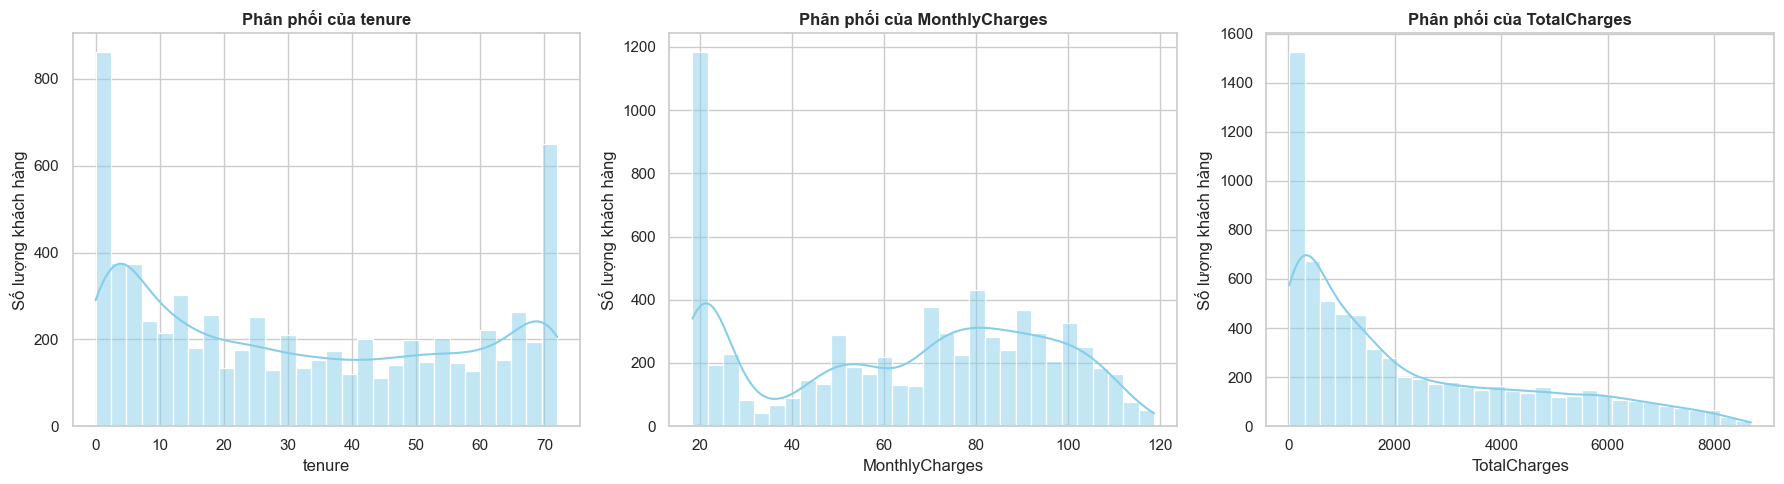


--- 2. VẼ BIỂU ĐỒ HỘP TÌM OUTLIERS (BOXPLOT) ---


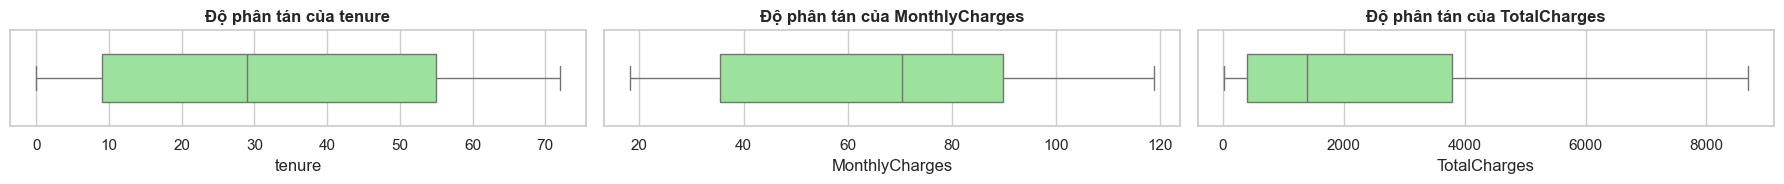


--- 3. KIỂM TRA TƯƠNG QUAN (CORRELATION HEATMAP) ---


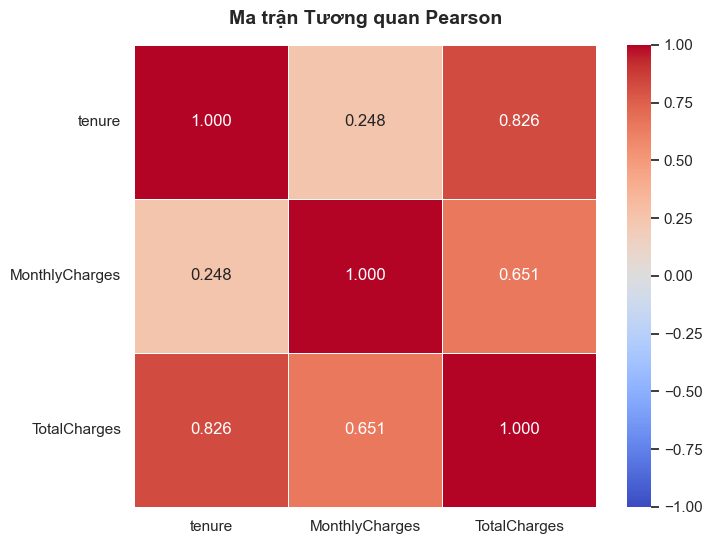

In [14]:

# Danh sách các biến liên tục cần phân tích
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

# Cài đặt giao diện Seaborn cho đẹp mắt
sns.set_theme(style="whitegrid", palette="muted")

# ==========================================
# 1. PHÂN TÍCH PHÂN PHỐI DỮ LIỆU (HISTOGRAM)
# ==========================================
print("--- 1. VẼ BIỂU ĐỒ PHÂN PHỐI (HISTOGRAM) ---")
plt.figure(figsize=(18, 5))
for i, col in enumerate(num_cols, 1):
    plt.subplot(1, 3, i)
    # Vẽ histogram kèm đường cong KDE để nhìn rõ xu hướng
    sns.histplot(df[col], kde=True, bins=30, color='skyblue')
    plt.title(f'Phân phối của {col}', fontweight='bold')
    plt.xlabel(col)
    plt.ylabel('Số lượng khách hàng')

plt.tight_layout()
plt.show()

# ==========================================
# 2. KIỂM TRA ĐIỂM DỊ BIỆT (BOXPLOT)
# ==========================================
print("\n--- 2. VẼ BIỂU ĐỒ HỘP TÌM OUTLIERS (BOXPLOT) ---")
plt.figure(figsize=(18, 2)) # Chiều cao ngắn lại vì boxplot nằm ngang
for i, col in enumerate(num_cols, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(x=df[col], color='lightgreen', width=0.5)
    plt.title(f'Độ phân tán của {col}', fontweight='bold')

plt.tight_layout()
plt.show()

# ==========================================
# 3. MA TRẬN TƯƠNG QUAN PEARSON (HEATMAP)
# ==========================================
print("\n--- 3. KIỂM TRA TƯƠNG QUAN (CORRELATION HEATMAP) ---")
plt.figure(figsize=(8, 6))

# Tính ma trận tương quan giữa 3 biến liên tục
corr_matrix = df[num_cols].corr()

# Vẽ Heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".3f", 
            vmin=-1, vmax=1, linewidths=0.5, square=True)

plt.title('Ma trận Tương quan Pearson', fontsize=14, fontweight='bold', pad=15)
plt.yticks(rotation=0)
plt.show()

- Tương quan của các biến với biển mục tiêu khá tốt 

# Trực quan từng cặp 

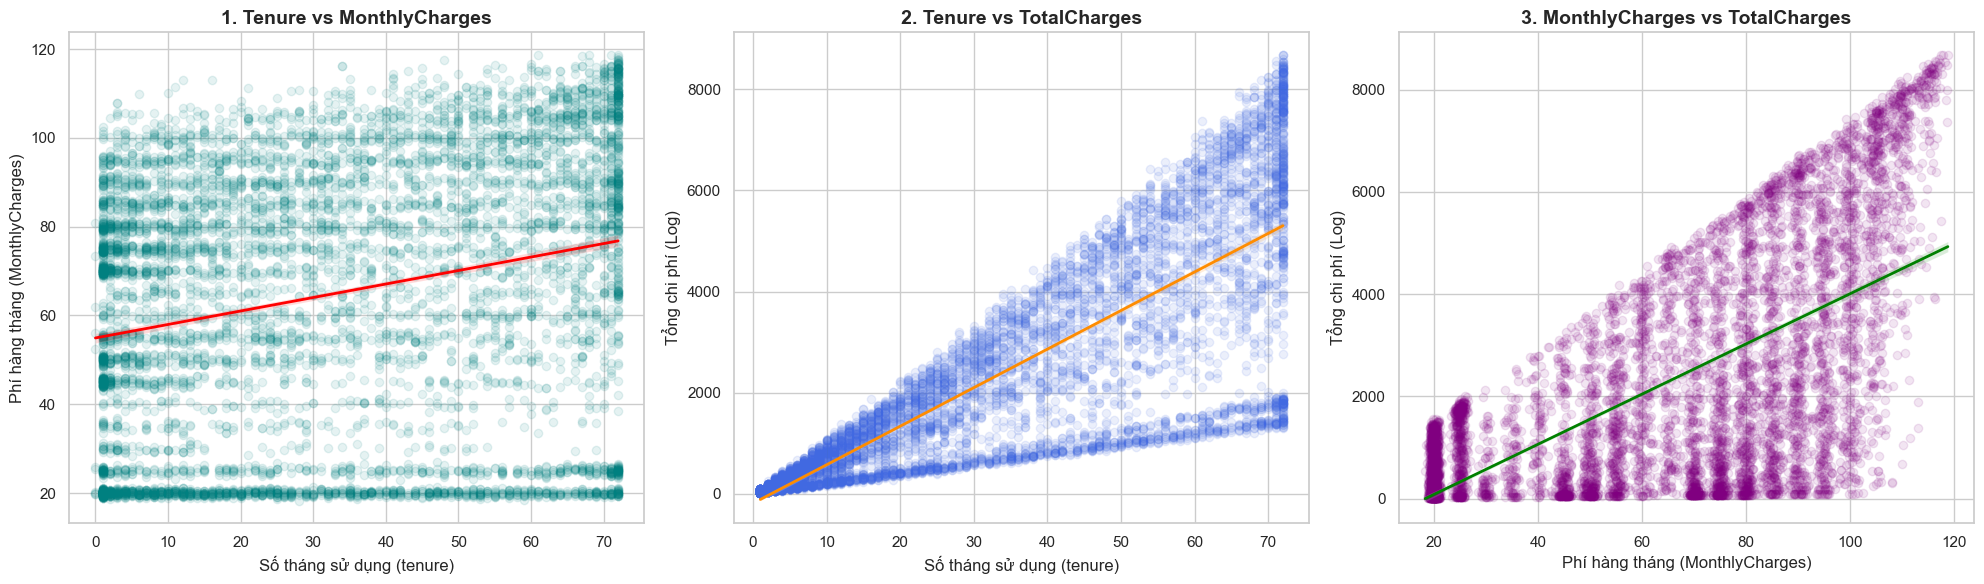

In [17]:


# Thiết lập giao diện nền trắng lưới mờ
sns.set_theme(style="whitegrid")

# Tạo một "bức tranh" lớn gồm 1 hàng và 3 cột, kích thước rộng 20, cao 6
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# =======================================================
# Ô số 1: Số tháng (tenure) vs Phí hàng tháng (MonthlyCharges)
# =======================================================
sns.regplot(data=df, x='tenure', y='MonthlyCharges', ax=axes[0],
            scatter_kws={'alpha': 0.1, 'color': 'teal'}, 
            line_kws={'color': 'red', 'linewidth': 2})
axes[0].set_title('1. Tenure vs MonthlyCharges', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Số tháng sử dụng (tenure)')
axes[0].set_ylabel('Phí hàng tháng (MonthlyCharges)')

# =======================================================
# Ô số 2: Số tháng (tenure) vs Tổng chi phí (TotalCharges)
# =======================================================
sns.regplot(data=df, x='tenure', y='TotalCharges', ax=axes[1],
            scatter_kws={'alpha': 0.1, 'color': 'royalblue'}, 
            line_kws={'color': 'darkorange', 'linewidth': 2})
axes[1].set_title('2. Tenure vs TotalCharges', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Số tháng sử dụng (tenure)')
axes[1].set_ylabel('Tổng chi phí (Log)')

# =======================================================
# Ô số 3: Phí hàng tháng (MonthlyCharges) vs Tổng chi phí  (TotalCharges)
# =======================================================
sns.regplot(data=df, x='MonthlyCharges', y='TotalCharges', ax=axes[2],
            scatter_kws={'alpha': 0.1, 'color': 'purple'}, 
            line_kws={'color': 'green', 'linewidth': 2})
axes[2].set_title('3. MonthlyCharges vs TotalCharges', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Phí hàng tháng (MonthlyCharges)')
axes[2].set_ylabel('Tổng chi phí (Log)')

# Căn chỉnh tự động để chữ không bị đè lên nhau
plt.tight_layout()
plt.show()

# Tính VIF 

In [19]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 1. Xác định danh sách các biến liên tục (X) và biến mục tiêu (Y)
# Sử dụng TotalCharges (hoặc TotalCharges) làm mục tiêu để loại bỏ ra khỏi tập X
df_continuous_features = df[['tenure', 'MonthlyCharges', 'TotalCharges']].copy()  
X_ = df_continuous_features.drop(columns=['TotalCharges'])

# 2 & 3. Encode biến phân loại 
# Hiện tại tập X_ chỉ có biến liên tục, nhưng vẫn giữ form này để bạn dễ mở rộng sau này
# Ví dụ: Nếu sau này muốn kiểm tra VIF của cả hợp đồng (Contract), bạn chỉ cần mở comment
# X_encoded = pd.get_dummies(
#     X_,
#     columns=['Contract'],
#     drop_first=True,
#     dtype=int
# )
X_encoded = X_.copy()

# 4. BẮT BUỘC: Thêm cột hằng số (constant) để thuật toán tính VIF chính xác
X_with_const = sm.add_constant(X_encoded)

# 5. Tính toán chỉ số VIF cho từng đặc trưng
vif_data = pd.DataFrame()
vif_data["Feature"] = X_with_const.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_with_const.values, i)
    for i in range(X_with_const.shape[1])
]

# In kết quả, làm tròn 4 chữ số thập phân
print("\n--- BÁO CÁO KIỂM TRA ĐA CỘNG TUYẾN (VIF) ---")
print(vif_data.round(4))


--- BÁO CÁO KIỂM TRA ĐA CỘNG TUYẾN (VIF) ---
          Feature     VIF
0           const  6.2888
1          tenure  1.0655
2  MonthlyCharges  1.0655


2 biến ko có hiện tượng đa cộng tuyến 

# Phân tích biến phân loại 

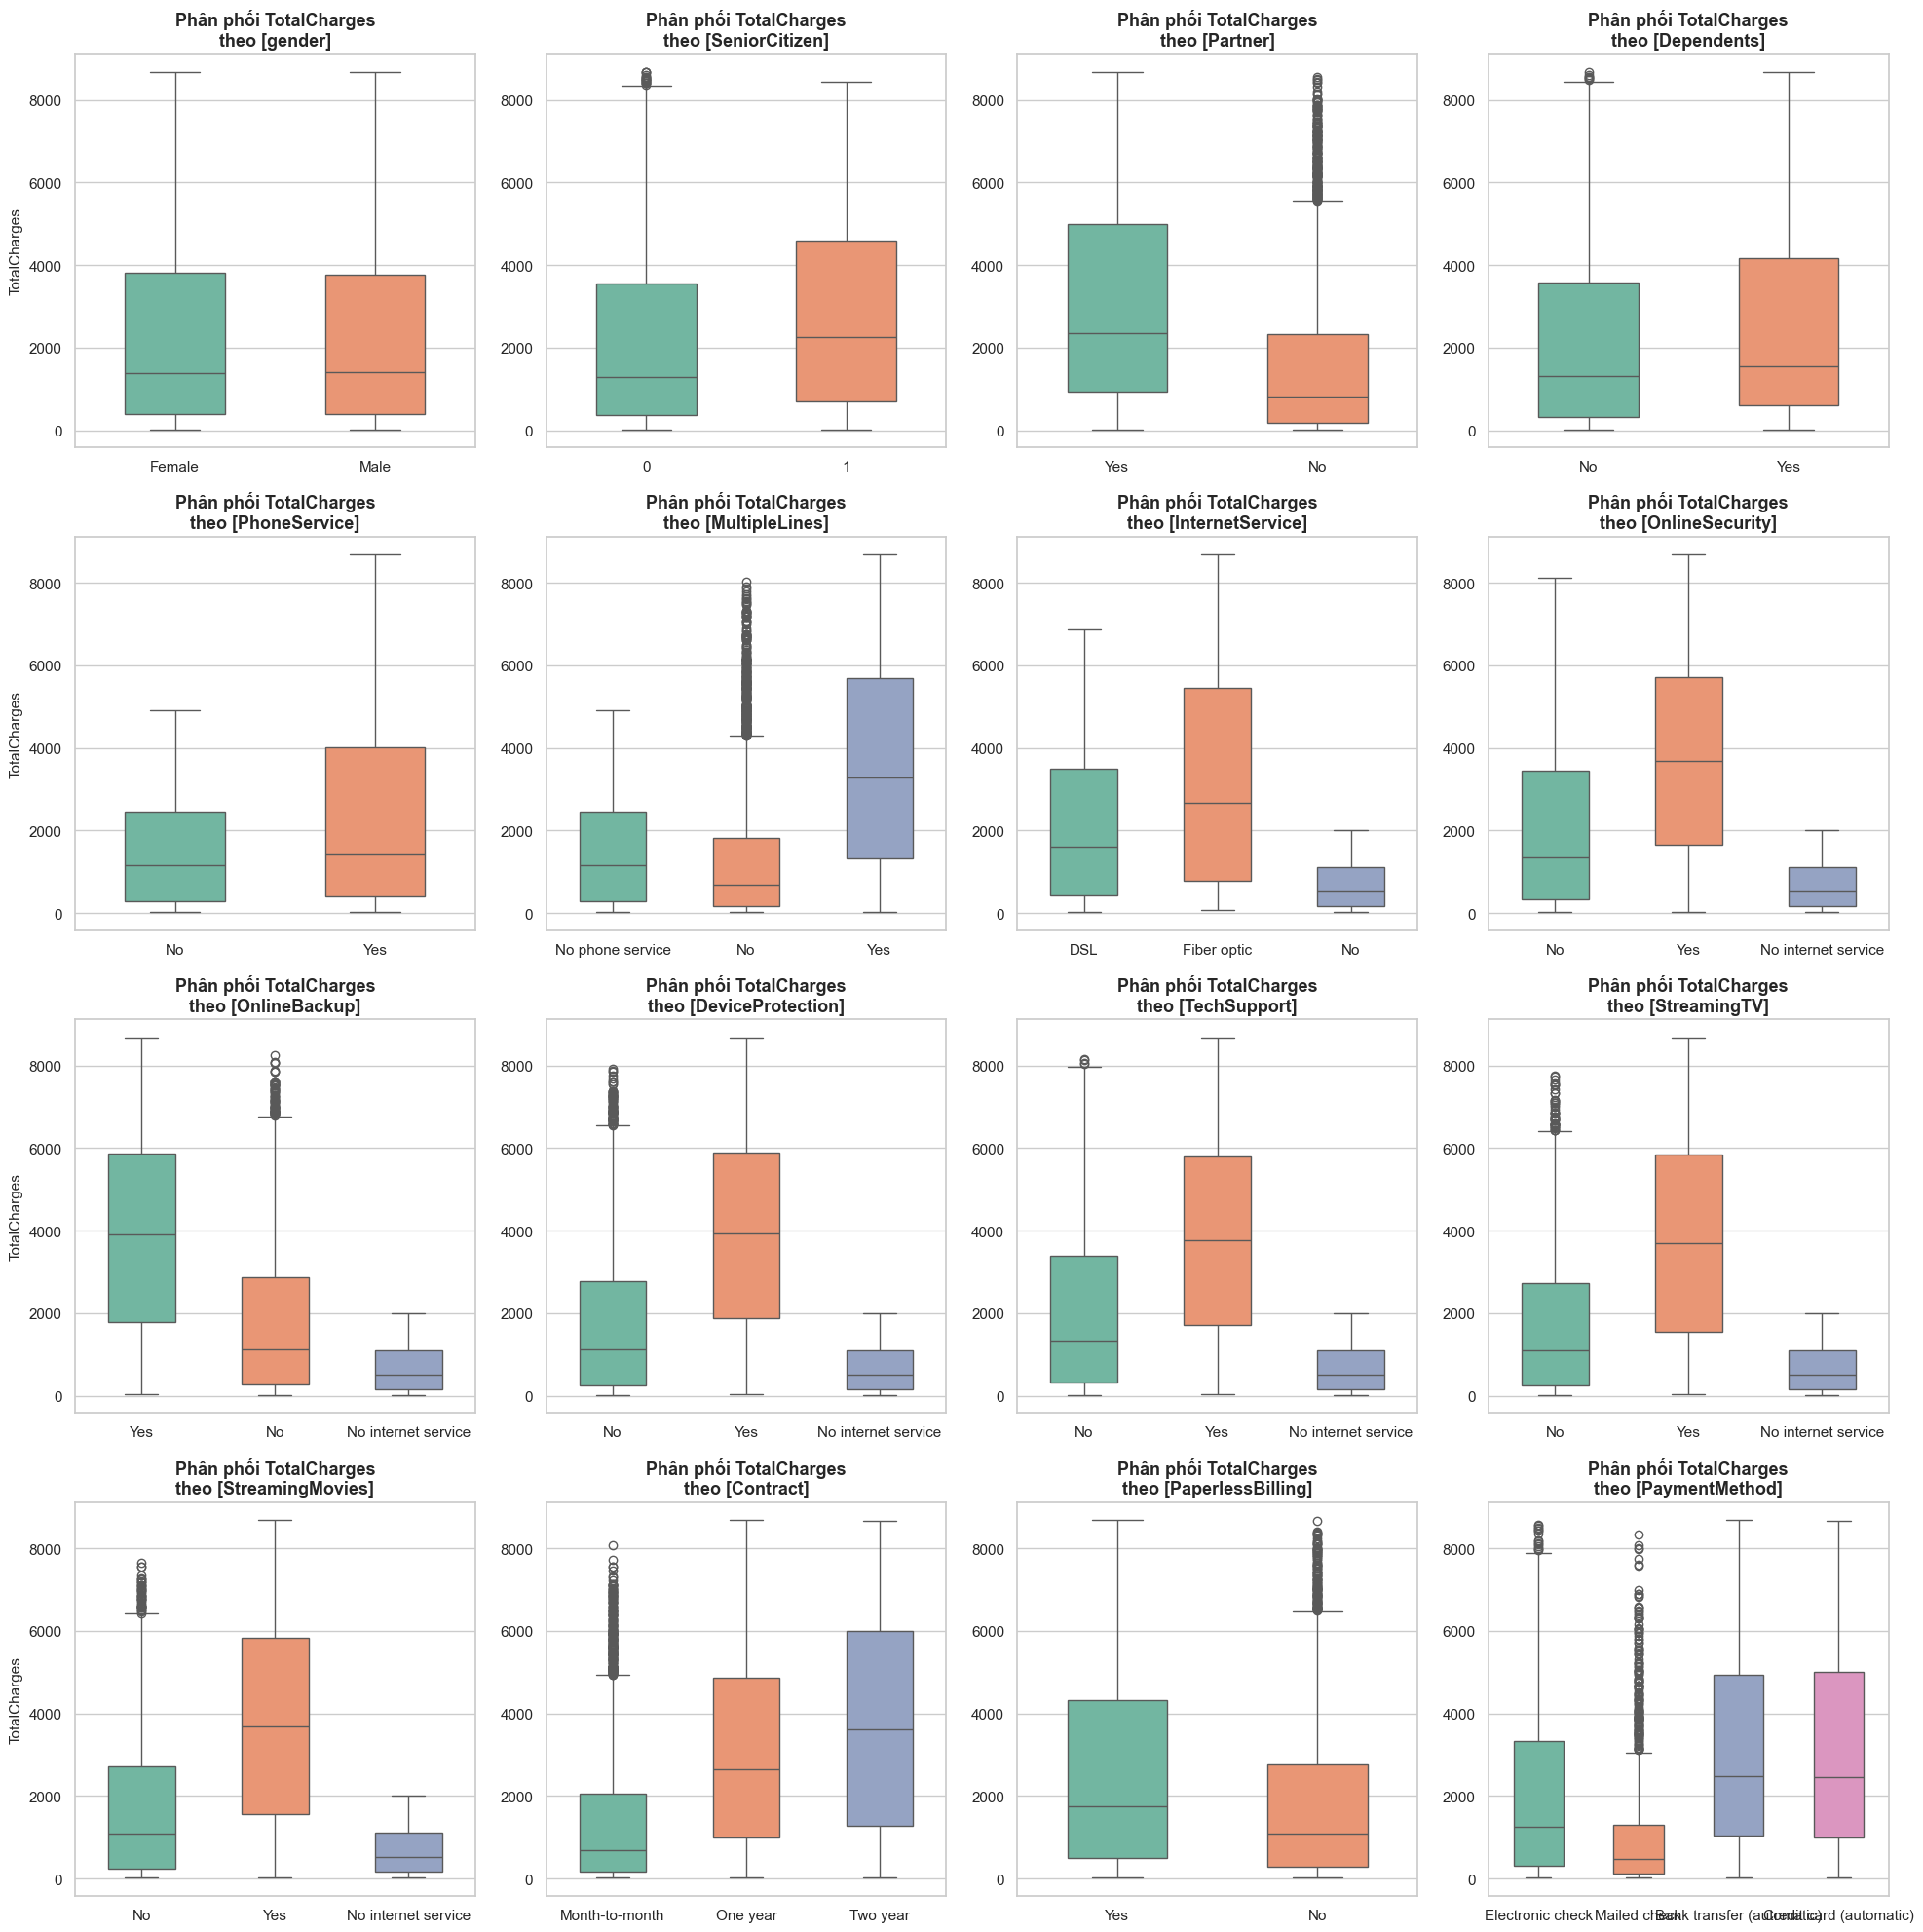

In [23]:

# ==========================================
# 1. CẤU HÌNH BIẾN MỤC TIÊU VÀ BIẾN PHÂN LOẠI
# ==========================================
target = 'TotalCharges'  # Ưu tiên dùng biến đã xử lý Logarit để Boxplot không bị méo

# Chọn ra các biến phân loại quan trọng muốn vẽ (Bạn có thể thêm bớt tùy ý)
cat_cols_telco = [
    # 1. Thông tin Nhân khẩu học (Demographics)
    'gender', 'SeniorCitizen', 'Partner', 'Dependents', 
    
    # 2. Dịch vụ Điện thoại (Phone Services)
    'PhoneService', 'MultipleLines', 
    
    # 3. Dịch vụ Internet & Tính năng bảo mật (Internet & Add-ons)
    'InternetService', 'OnlineSecurity', 'OnlineBackup', 
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 
    
    # 4. Thông tin Hợp đồng & Thanh toán (Billing & Contract)
    'Contract', 'PaperlessBilling', 'PaymentMethod'
]
# ==========================================
# 2. THUẬT TOÁN TỰ ĐỘNG CHIA LƯỚI (DYNAMIC GRID)
# ==========================================
n_features = len(cat_cols_telco)
n_cols_grid = 4  # Chốt cứng số cột ngang (4 biểu đồ trên 1 hàng cho dễ nhìn)

# Tự động làm tròn lên để tính số hàng cần thiết (Ví dụ: 8 biến / 4 = 2 hàng)
n_rows_grid = math.ceil(n_features / n_cols_grid) 

# ==========================================
# 3. VẼ VÀ TRANG TRÍ BIỂU ĐỒ
# ==========================================
sns.set_theme(style="whitegrid")

# Kích thước khung tự động giãn nở: Ngang 20, Cao bằng [Số hàng * 5]
plt.figure(figsize=(20, 5 * n_rows_grid)) 

for i, col in enumerate(cat_cols_telco, 1):
    # Khởi tạo từng ô con bằng lưới động đã tính ở trên
    ax = plt.subplot(n_rows_grid, n_cols_grid, i)
    
    # Vẽ Boxplot (thêm palette màu để tách biệt các nhóm dễ hơn)
    sns.boxplot(x=col, y=target, data=df, width=0.5, palette="Set2", hue=col, legend=False)
    
    # Trang trí biểu đồ con
    ax.set_title(f'Phân phối {target}\ntheo [{col}]', fontsize=13, fontweight='bold')
    ax.set_xlabel('') # Tạm ẩn tên trục X vì tiêu đề đã ghi rõ tên cột
    
    # Kỹ thuật ẩn trục Y thông minh: Chỉ hiện nhãn Y ở biểu đồ nằm ngoài cùng bên trái của mỗi hàng
    if i % n_cols_grid == 1:
        ax.set_ylabel(target, fontsize=11)
    else:
        ax.set_ylabel("")

# Tự động dàn đều để chữ không đè lên nhau
plt.tight_layout()
plt.show()

# Kiểm định 

# 2 biến 

In [25]:

def filter_by_welch_ttest_eta(df, binary_col, target_col):
    # 1. Làm sạch dữ liệu
    valid_data = df[[binary_col, target_col]].dropna()
    groups = valid_data[binary_col].unique()

    # 2. Tách dữ liệu thành 2 nhóm
    group1 = valid_data[valid_data[binary_col] == groups[0]][target_col].values
    group2 = valid_data[valid_data[binary_col] == groups[1]][target_col].values

    # 3. Chạy kiểm định Welch's T-test
    t_stat, p_value = stats.ttest_ind(group1, group2, equal_var=False)

    # 4. TÍNH TOÁN ETA-SQUARED (Mức độ giải thích sự biến thiên)
    n1, n2 = len(group1), len(group2)
    df_degrees = n1 + n2 - 2
    eta_squared = (t_stat**2) / ((t_stat**2) + df_degrees)
    
    # Đổi ra phần trăm cho dễ đọc
    eta_pct = eta_squared * 100

    # 5. Kết luận dựa trên ngưỡng 0.05
    conclusion = " GIỮ LẠI" if p_value < 0.05 else "❌ LOẠI BỎ"

    # In báo cáo với Bảng xếp hạng sức mạnh
    print(f" T-TEST BIẾN: [{binary_col}]")
    print(f"   p-value      : {p_value:.6f}  ->  {conclusion}")
    print(f"   Eta-squared  : {eta_pct:.2f}% (Biến này quyết định {eta_pct:.2f}% tổng chi phí)")
    print("-" * 55)

# ==========================================
# CÁCH ÁP DỤNG VÀO BỘ DỮ LIỆU TELCO
# ==========================================
binary_cols_telco = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']
target = 'TotalCharges'

print("=" * 55)
print("BÁO CÁO: XẾP HẠNG SỨC MẠNH BIẾN NHỊ PHÂN (KÈM ETA-SQUARED)")
print("=" * 55)

for col in binary_cols_telco:
    filter_by_welch_ttest_eta(df, col, target)

BÁO CÁO: XẾP HẠNG SỨC MẠNH BIẾN NHỊ PHÂN (KÈM ETA-SQUARED)
 T-TEST BIẾN: [gender]
   p-value      : 0.996800  ->  ❌ LOẠI BỎ
   Eta-squared  : 0.00% (Biến này quyết định 0.00% tổng chi phí)
-------------------------------------------------------
 T-TEST BIẾN: [SeniorCitizen]
   p-value      : 0.000000  ->   GIỮ LẠI
   Eta-squared  : 0.97% (Biến này quyết định 0.97% tổng chi phí)
-------------------------------------------------------
 T-TEST BIẾN: [Partner]
   p-value      : 0.000000  ->   GIỮ LẠI
   Eta-squared  : 10.02% (Biến này quyết định 10.02% tổng chi phí)
-------------------------------------------------------
 T-TEST BIẾN: [Dependents]
   p-value      : 0.000000  ->   GIỮ LẠI
   Eta-squared  : 0.41% (Biến này quyết định 0.41% tổng chi phí)
-------------------------------------------------------
 T-TEST BIẾN: [PhoneService]
   p-value      : 0.000000  ->   GIỮ LẠI
   Eta-squared  : 2.96% (Biến này quyết định 2.96% tổng chi phí)
---------------------------------------------------

# 3 biến trở lên 

In [ ]:


def filter_by_anova_eta(df, cat_col, target_col):
    """
    Hàm chạy One-Way ANOVA và tính toán Eta-squared cho biến có >= 3 nhóm.
    """
    # 1. Làm sạch dữ liệu rác/khuyết thiếu
    valid_data = df[[cat_col, target_col]].dropna()
    
    # 2. Lấy danh sách các nhóm và kiểm tra điều kiện
    categories = valid_data[cat_col].unique()
    k = len(categories) # Số lượng nhóm
    
    if k < 3:
        print(f" BỎ QUA: [{cat_col}] chỉ có {k} nhóm. Vui lòng dùng Welch's T-test thay thế!")
        return None

    # 3. Tách dữ liệu thành các mảng nhỏ tương ứng với từng nhóm
    groups_data = [valid_data[valid_data[cat_col] == cat][target_col].values for cat in categories]
    
    # 4. Chạy kiểm định One-Way ANOVA
    f_stat, p_value = stats.f_oneway(*groups_data)
    
    # 5. Tính toán Eta-squared (η²)
    N = len(valid_data)          # Tổng số quan sát
    df_between = k - 1           # Bậc tự do giữa các nhóm
    df_within = N - k            # Bậc tự do trong nội bộ nhóm
    
    eta_squared = (f_stat * df_between) / ((f_stat * df_between) + df_within)
    eta_pct = eta_squared * 100  # Đổi ra phần trăm
    
    # 6. Đưa ra kết luận (Người gác cổng p-value)
    conclusion = " GIỮ LẠI" if p_value < 0.05 else "❌ LOẠI BỎ"
    
    # In báo cáo
    print(f" ĐÁNH GIÁ BIẾN ĐA NHÓM: [{cat_col}] ({k} nhóm)")
    print(f"   p-value      : {p_value:.6f}  ->  {conclusion}")
    print(f"   Eta-squared  : {eta_pct:.2f}% (Giải thích được {eta_pct:.2f}% sự biến thiên của {target_col})")
    print("-" * 65)

# ==========================================
# CÁCH ÁP DỤNG VÀO BỘ DỮ LIỆU TELCO
# ==========================================
# Danh sách các cột có từ 3 nhãn trở lên trong Telco
multi_cols_telco = ['MultipleLines', 'InternetService', 'Contract', 'PaymentMethod','OnlineSecurity',
                    'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies','PaymentMethod']
# Biến mục tiêu 
target = 'TotalCharges'

print("=" * 65)
print("BÁO CÁO: XẾP HẠNG SỨC MẠNH BIẾN ĐA NHÓM (ANOVA + ETA-SQUARED)")
print("=" * 65)

for col in multi_cols_telco:
    filter_by_anova_eta(df, col, target)

BÁO CÁO: XẾP HẠNG SỨC MẠNH BIẾN ĐA NHÓM (ANOVA + ETA-SQUARED)


KeyError: "['TotalCharges_Log'] not in index"

sau khi kiểm định thì còn lại 19 đặc trưng 

# Dùng thuật toán Lasso

1. Đang chuẩn hóa dữ liệu để Lasso phạt công bằng...
2. Máy tính đang tự động tìm kiếm mức phạt Alpha tối ưu...
-> Mức phạt (Alpha) hoàn hảo máy tìm được là: 0.7377
3. Đang xuất Báo cáo sinh tử của các đặc trưng...

=== KẾT QUẢ: LASSO GIỮ LẠI 23 BIẾN, XÓA SỔ 7 BIẾN ===


C:\Users\Admin\AppData\Local\Temp\ipykernel_20788\2105110291.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=survivors,


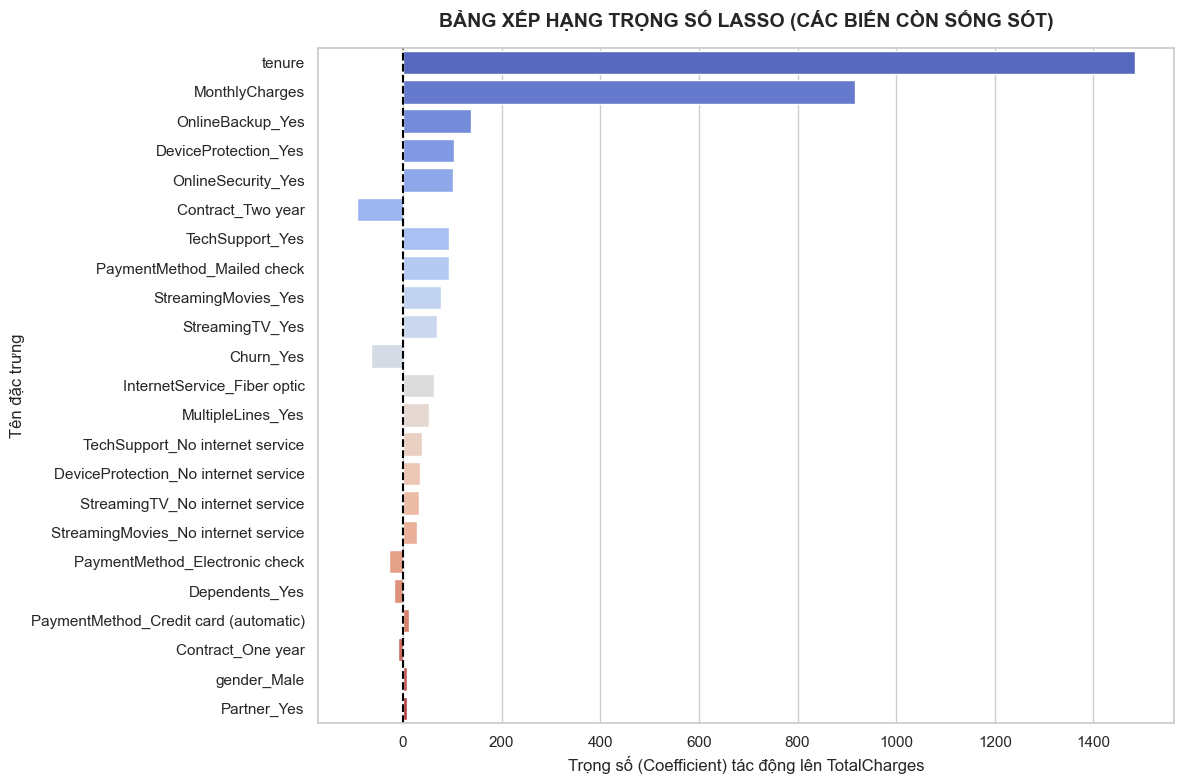


--- NHỮNG BIẾN BỊ LASSO ÉP VỀ 0 (NÊN XÓA BỎ) ---
['PhoneService_Yes', 'MultipleLines_No phone service', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineBackup_No internet service', 'PaperlessBilling_Yes', 'SeniorCitizen_1']


In [ ]:


# ==========================================
# BƯỚC 1: CHUẨN BỊ DỮ LIỆU VÀ CHUẨN HÓA (SCALING)
# Giả sử X_encoded đang chứa 19 đặc trưng của bạn, và y là TotalCharges
# ==========================================
print("1. Đang chuẩn hóa dữ liệu để Lasso phạt công bằng...")

# Khởi tạo công cụ chuẩn hóa
scaler = StandardScaler()

# Kéo tất cả 19 cột về cùng một hệ quy chiếu (Trung bình = 0, Độ lệch chuẩn = 1)
X_scaled = scaler.fit_transform(X_encoded)

# ==========================================
# BƯỚC 2: HUẤN LUYỆN LASSO TÌM MỨC PHẠT TỐI ƯU
# ==========================================
print("2. Máy tính đang tự động tìm kiếm mức phạt Alpha tối ưu...")

# Khởi tạo LassoCV: Thử 1000 mức phạt khác nhau, chia tập dữ liệu làm 5 phần để thi chéo (cv=5)
lasso_model = LassoCV(alphas=np.logspace(-4, 4, 1000), cv=5, random_state=42, max_iter=10000)

# Tiến hành "trảm" các biến yếu
lasso_model.fit(X_scaled, y)

print(f"-> Mức phạt (Alpha) hoàn hảo máy tìm được là: {lasso_model.alpha_:.4f}")

# ==========================================
# BƯỚC 3: RÚT TRÍCH TRỌNG SỐ VÀ LỌC BIẾN
# ==========================================
print("3. Đang xuất Báo cáo sinh tử của các đặc trưng...\n")

# Tạo bảng chứa tên cột và trọng số (Coefficient) tương ứng
lasso_coefs = pd.DataFrame({
    'Feature': X_encoded.columns,
    'Coefficient': lasso_model.coef_
})

# Tính độ lớn tuyệt đối của trọng số để dễ sắp xếp
lasso_coefs['Absolute_Coef'] = lasso_coefs['Coefficient'].abs()

# Lọc ra những biến "Sống sót" (Trọng số KHÁC 0)
survivors = lasso_coefs[lasso_coefs['Absolute_Coef'] > 0].sort_values(by='Absolute_Coef', ascending=False)

# Lọc ra những biến bị "Xóa sổ" (Trọng số BẰNG 0)
eliminated = lasso_coefs[lasso_coefs['Absolute_Coef'] == 0]

print(f"=== KẾT QUẢ: LASSO GIỮ LẠI {len(survivors)} BIẾN, XÓA SỔ {len(eliminated)} BIẾN ===")

# ==========================================
# BƯỚC 4: VẼ BIỂU ĐỒ CÁC BIẾN SỐNG SÓT
# ==========================================
plt.figure(figsize=(12, 8))
sns.set_theme(style="whitegrid")

# Vẽ biểu đồ ngang, thể hiện trọng số (có thể âm hoặc dương)
# Biến nào cột càng dài (về bên phải hoặc trái) thì sức mạnh càng lớn
ax = sns.barplot(data=survivors, 
                 x='Coefficient', 
                 y='Feature', 
                 palette='coolwarm')

plt.title('BẢNG XẾP HẠNG TRỌNG SỐ LASSO (CÁC BIẾN CÒN SỐNG SÓT)', 
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Trọng số (Coefficient) tác động lên TotalCharges', fontsize=12)
plt.ylabel('Tên đặc trưng', fontsize=12)

# Thêm đường số 0 ở giữa để phân biệt tác động Tăng/Giảm tiền
plt.axvline(x=0, color='black', linestyle='--', linewidth=1.5)

plt.tight_layout()
plt.show()

# In danh sách các biến bị xóa sổ để bạn biết
if len(eliminated) > 0:
    print("\n--- NHỮNG BIẾN BỊ LASSO ÉP VỀ 0 (NÊN XÓA BỎ) ---")
    print(eliminated['Feature'].to_list())

In [ ]:
# 1. Trích xuất tên của 9 đặc trưng mạnh nhất từ biểu đồ Lasso
top_9_features = survivors.head(9)['Feature'].tolist()

print("--- 9 ĐẶC TRƯNG ĐƯỢC GIỮ LẠI ---")
for i, feature in enumerate(top_9_features, 1):
    print(f"{i}. {feature}")

# 2. Tạo tập dữ liệu mới chỉ với 9 biến này
X_final = X_encoded[top_9_features]

# 3. Chia tập dữ liệu để huấn luyện (80% học, 20% thi)
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

X_train, X_test, y_train, y_test = train_test_split(X_final, y, test_size=0.2, random_state=42)

--- 9 ĐẶC TRƯNG ĐƯỢC GIỮ LẠI ---
1. tenure
2. MonthlyCharges
3. OnlineBackup_Yes
4. DeviceProtection_Yes
5. OnlineSecurity_Yes
6. Contract_Two year
7. TechSupport_Yes
8. PaymentMethod_Mailed check
9. StreamingMovies_Yes


# Huấn luyện mô hình 

In [ ]:


# ==========================================
# 1. CẤU HÌNH DỮ LIỆU ĐÃ CHỌN (9 BIẾN TINH HOA)
# ==========================================
features_list = [
    'tenure', 'MonthlyCharges', 'OnlineBackup_Yes', 'DeviceProtection_Yes', 
    'OnlineSecurity_Yes', 'Contract_Two year', 'TechSupport_Yes', 
    'PaymentMethod_Mailed check', 'StreamingMovies_Yes'
]

# Chuyển dữ liệu sang kiểu float ngay từ đầu để tránh lỗi dtype
X = X_encoded[features_list].astype(float).copy()
y = df['TotalCharges'].astype(float).copy()

# Thêm hằng số vào X
X_with_const = sm.add_constant(X)

# ==========================================
# 2. CẤU HÌNH K-FOLD CROSS VALIDATION
# ==========================================
n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

mae_scores = []
r2_scores = []

print(f"--- ĐANG CHẠY OLS CROSS-VALIDATION VỚI {n_splits} FOLDS ---")

# Lưu lại mô hình của fold cuối cùng để xem tóm tắt sau vòng lặp
final_model = None

for fold, (train_idx, test_idx) in enumerate(kf.split(X_with_const), 1):
    # Chia dữ liệu theo chỉ số dòng
    X_train, X_test = X_with_const.iloc[train_idx], X_with_const.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    # Huấn luyện mô hình OLS
    ols_model = sm.OLS(y_train, X_train).fit()
    final_model = ols_model # Lưu lại để xuất summary cuối cùng
    
    # Dự đoán
    y_pred = ols_model.predict(X_test)
    
    # Đánh giá
    fold_mae = mean_absolute_error(y_test, y_pred)
    fold_r2 = r2_score(y_test, y_pred)
    
    mae_scores.append(fold_mae)
    r2_scores.append(fold_r2)
    
    print(f"Fold {fold}: R² = {fold_r2:.4f} | MAE = ${fold_mae:,.2f}")

# ==========================================
# 3. KẾT LUẬN CUỐI CÙNG
# ==========================================
print("\n" + "="*55)
print("BẢNG TỔNG KẾT HIỆU SUẤT TRUNG BÌNH (MÔ HÌNH 9 BIẾN)")
print(f"-> R² Trung bình  : {np.mean(r2_scores):.4f} (+/- {np.std(r2_scores):.4f})")
print(f"-> MAE Trung bình : ${np.mean(mae_scores):,.2f}")
print("="*55)

# Hiển thị bảng tóm tắt của lần chạy cuối cùng
if final_model:
    print("\nBẢNG HỆ SỐ HỒI QUY CHI TIẾT (LẦN CHẠY CUỐI):")
    print(final_model.summary().tables[1])

--- ĐANG CHẠY OLS CROSS-VALIDATION VỚI 5 FOLDS ---
Fold 1: R² = 0.9104 | MAE = $544.60
Fold 2: R² = 0.9105 | MAE = $554.18
Fold 3: R² = 0.9034 | MAE = $569.22
Fold 4: R² = 0.8989 | MAE = $582.40
Fold 5: R² = 0.8969 | MAE = $579.71

BẢNG TỔNG KẾT HIỆU SUẤT TRUNG BÌNH (MÔ HÌNH 9 BIẾN)
-> R² Trung bình  : 0.9040 (+/- 0.0057)
-> MAE Trung bình : $566.02

BẢNG HỆ SỐ HỒI QUY CHI TIẾT (LẦN CHẠY CUỐI):
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const                      -2148.6317     30.308    -70.894      0.000   -2208.047   -2089.217
tenure                        63.7252      0.532    119.800      0.000      62.682      64.768
MonthlyCharges                31.7274      0.485     65.461      0.000      30.777      32.678
OnlineBackup_Yes             237.8674     23.150     10.275      0.000     192.485     283.250
DeviceProtection_Yes         180